# Trabalho Prático 01 - Classificação KNN
### GCC 128 - Inteligência Artificial
**Professores:** Ahmed Ali Abdalla Esmin

**Aluno:** _Tobias Maugus Bueno Cougo_

---
Este notebook implementa o algoritmo **KNN (K-Nearest Neighbors)** do zero (*hardcore*), sem uso de bibliotecas que já o implementem, e também com o auxílio do **Scikit-learn**, aplicando-o na base de dados **Iris**. Ao final, é feita uma comparação de desempenho entre as duas implementações.

## 1. Importação das bibliotecas

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, accuracy_score,
                              classification_report)

# Observação: o Scikit-learn é utilizado aqui apenas para carregar a base de
# dados, dividir treino/teste e calcular métricas de avaliação (matriz de
# confusão, precisão, revocação, acurácia). O algoritmo KNN em si é
# implementado manualmente na Seção 3.

np.random.seed(42)


## 2. Carregamento e preparação da base de dados Iris
A base **Iris** possui 150 amostras de flores, divididas em 3 classes
(*setosa*, *versicolor*, *virginica*), com 4 atributos numéricos
(comprimento/largura de sépala e pétala).

In [10]:
iris = load_iris()
X = iris.data
y = iris.target
nomes_classes = iris.target_names

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [nomes_classes[i] for i in y]

print(f"Formato da base: {df.shape}")
df.head()


Formato da base: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
# Divisão em conjunto de treino (70%) e teste (30%), estratificada por classe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Amostras de treino: {X_train.shape[0]}")
print(f"Amostras de teste : {X_test.shape[0]}")


Amostras de treino: 105
Amostras de teste : 45


## 3. Implementação do KNN "do zero" (hardcore)

O algoritmo KNN classifica uma nova amostra observando os **k** vizinhos mais
próximos (segundo a distância Euclidiana) no conjunto de treino, e atribuindo
a ela a classe mais frequente entre esses vizinhos (votação majoritária).

In [12]:
class KNNHardcore:
    """Implementação do algoritmo K-Nearest Neighbors desenvolvida do zero."""

    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # KNN é um algoritmo "lazy" (preguiçoso): treinar = apenas guardar os dados
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distancia_euclidiana(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    def _prever_uma_amostra(self, x):
        # 1) Calcula a distância de x para todos os pontos de treino
        distancias = [self._distancia_euclidiana(x, x_treino) for x_treino in self.X_train]

        # 2) Seleciona os índices dos k vizinhos mais próximos
        k_indices = np.argsort(distancias)[:self.k]

        # 3) Recupera os rótulos desses k vizinhos
        k_rotulos = self.y_train[k_indices]

        # 4) Votação majoritária -> classe mais frequente entre os vizinhos
        valores, contagens = np.unique(k_rotulos, return_counts=True)
        return valores[np.argmax(contagens)]

    def predict(self, X):
        X = np.array(X)
        return np.array([self._prever_uma_amostra(x) for x in X])


## 4. Taxa de reconhecimento (acurácia) para k = {1, 3, 5, 7} — Implementação Hardcore

In [13]:
resultados_hardcore = {}
tempos_hardcore = {}

for k in [1, 3, 5, 7]:
    modelo = KNNHardcore(k=k)
    modelo.fit(X_train, y_train)

    inicio = time.time()
    y_pred = modelo.predict(X_test)
    fim = time.time()

    acc = accuracy_score(y_test, y_pred)
    resultados_hardcore[k] = acc
    tempos_hardcore[k] = fim - inicio

    print(f"k = {k}  ->  Taxa de reconhecimento (acurácia) = {acc:.4f}  "
          f"({acc*100:.2f}%)   | tempo de predição: {fim - inicio:.4f}s")


k = 1  ->  Taxa de reconhecimento (acurácia) = 0.9333  (93.33%)   | tempo de predição: 0.1473s
k = 3  ->  Taxa de reconhecimento (acurácia) = 0.9556  (95.56%)   | tempo de predição: 0.0843s
k = 5  ->  Taxa de reconhecimento (acurácia) = 0.9778  (97.78%)   | tempo de predição: 0.0470s
k = 7  ->  Taxa de reconhecimento (acurácia) = 0.9556  (95.56%)   | tempo de predição: 0.0484s


In [14]:
tabela_hardcore = pd.DataFrame({
    'k': list(resultados_hardcore.keys()),
    'Acurácia': list(resultados_hardcore.values()),
    'Tempo (s)': list(tempos_hardcore.values())
})
tabela_hardcore


,k,Acurácia,Tempo (s)
0,1,0.933333,0.147303
1,3,0.955556,0.084254
2,5,0.977778,0.046974
3,7,0.955556,0.048440


## 5. Matriz de confusão e métricas de avaliação — Implementação Hardcore

Utiliza-se o melhor valor de **k** encontrado acima para gerar a matriz de
confusão e reportar **precisão**, **revocação** e **acurácia** (médias
*macro*, adequadas para problemas multiclasse balanceados como o Iris).

In [15]:
melhor_k_hardcore = max(resultados_hardcore, key=resultados_hardcore.get)
print(f"Melhor k (hardcore): {melhor_k_hardcore}")

modelo_hardcore_final = KNNHardcore(k=melhor_k_hardcore)
modelo_hardcore_final.fit(X_train, y_train)
y_pred_hardcore = modelo_hardcore_final.predict(X_test)

acc_hardcore = accuracy_score(y_test, y_pred_hardcore)
prec_hardcore = precision_score(y_test, y_pred_hardcore, average='macro')
rec_hardcore = recall_score(y_test, y_pred_hardcore, average='macro')
cm_hardcore = confusion_matrix(y_test, y_pred_hardcore)

print(f"Acurácia : {acc_hardcore:.4f}")
print(f"Precisão : {prec_hardcore:.4f}")
print(f"Revocação: {rec_hardcore:.4f}")
print()
print(classification_report(y_test, y_pred_hardcore, target_names=nomes_classes))


Melhor k (hardcore): 5
Acurácia : 0.9778
Precisão : 0.9792
Revocação: 0.9778

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



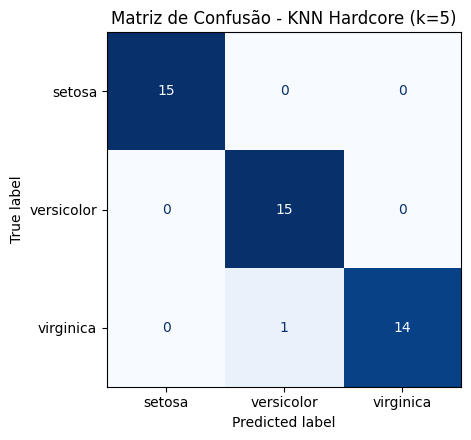

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hardcore, display_labels=nomes_classes)
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"Matriz de Confusão - KNN Hardcore (k={melhor_k_hardcore})")
plt.tight_layout()
plt.show()


## 6. Implementação utilizando Scikit-learn

Repete-se o mesmo experimento (k = {1, 3, 5, 7}) utilizando a implementação
já pronta do `KNeighborsClassifier`.

In [17]:
from sklearn.neighbors import KNeighborsClassifier

resultados_sklearn = {}
tempos_sklearn = {}

for k in [1, 3, 5, 7]:
    modelo = KNeighborsClassifier(n_neighbors=k)

    inicio = time.time()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    fim = time.time()

    acc = accuracy_score(y_test, y_pred)
    resultados_sklearn[k] = acc
    tempos_sklearn[k] = fim - inicio

    print(f"k = {k}  ->  Taxa de reconhecimento (acurácia) = {acc:.4f}  "
          f"({acc*100:.2f}%)   | tempo (fit+predict): {fim - inicio:.4f}s")


k = 1  ->  Taxa de reconhecimento (acurácia) = 0.9333  (93.33%)   | tempo (fit+predict): 0.0154s
k = 3  ->  Taxa de reconhecimento (acurácia) = 0.9556  (95.56%)   | tempo (fit+predict): 0.0084s
k = 5  ->  Taxa de reconhecimento (acurácia) = 0.9778  (97.78%)   | tempo (fit+predict): 0.0040s
k = 7  ->  Taxa de reconhecimento (acurácia) = 0.9556  (95.56%)   | tempo (fit+predict): 0.0015s


In [18]:
tabela_sklearn = pd.DataFrame({
    'k': list(resultados_sklearn.keys()),
    'Acurácia': list(resultados_sklearn.values()),
    'Tempo (s)': list(tempos_sklearn.values())
})
tabela_sklearn


,k,Acurácia,Tempo (s)
0,1,0.933333,0.015438
1,3,0.955556,0.008371
2,5,0.977778,0.004019
3,7,0.955556,0.001509


## 7. Matriz de confusão e métricas de avaliação — Scikit-learn

In [19]:
melhor_k_sklearn = max(resultados_sklearn, key=resultados_sklearn.get)
print(f"Melhor k (sklearn): {melhor_k_sklearn}")

modelo_sklearn_final = KNeighborsClassifier(n_neighbors=melhor_k_sklearn)
modelo_sklearn_final.fit(X_train, y_train)
y_pred_sklearn = modelo_sklearn_final.predict(X_test)

acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
prec_sklearn = precision_score(y_test, y_pred_sklearn, average='macro')
rec_sklearn = recall_score(y_test, y_pred_sklearn, average='macro')
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)

print(f"Acurácia : {acc_sklearn:.4f}")
print(f"Precisão : {prec_sklearn:.4f}")
print(f"Revocação: {rec_sklearn:.4f}")
print()
print(classification_report(y_test, y_pred_sklearn, target_names=nomes_classes))


Melhor k (sklearn): 5
Acurácia : 0.9778
Precisão : 0.9792
Revocação: 0.9778

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



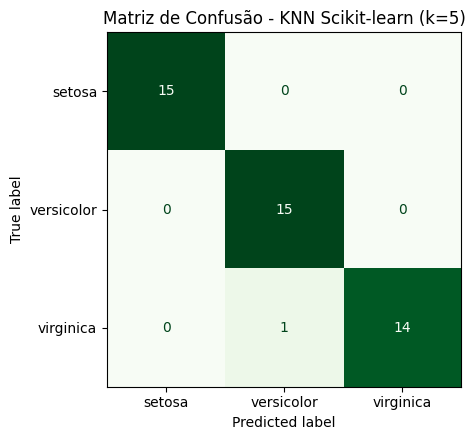

In [20]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn, display_labels=nomes_classes)
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title(f"Matriz de Confusão - KNN Scikit-learn (k={melhor_k_sklearn})")
plt.tight_layout()
plt.show()


## 8. Comparação de desempenho entre as duas implementações

In [21]:
comparacao = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão (macro)', 'Revocação (macro)'],
    'KNN Hardcore': [acc_hardcore, prec_hardcore, rec_hardcore],
    'KNN Scikit-learn': [acc_sklearn, prec_sklearn, rec_sklearn]
})
comparacao['Diferença'] = comparacao['KNN Hardcore'] - comparacao['KNN Scikit-learn']
comparacao


,Métrica,KNN Hardcore,KNN Scikit-learn,Diferença
0,Acurácia,0.977778,0.977778,0.0
1,Precisão (macro),0.979167,0.979167,0.0
2,Revocação (macro),0.977778,0.977778,0.0


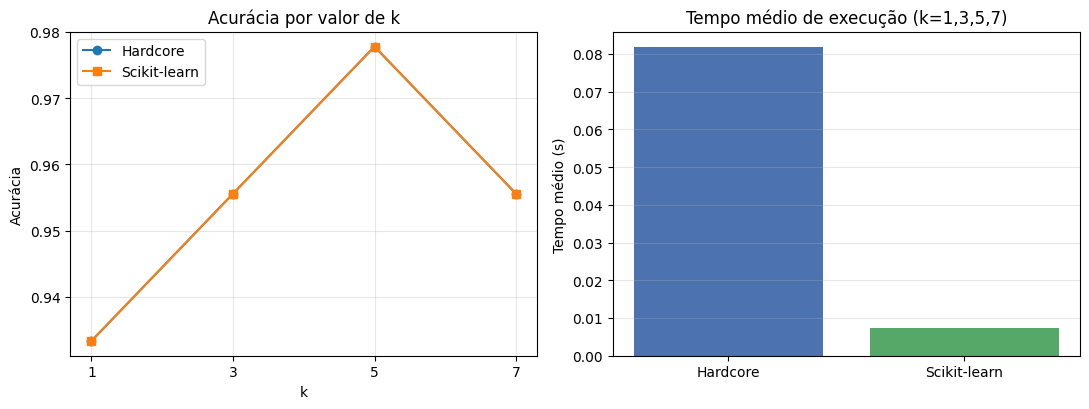

Tempo médio Hardcore   : 0.0817s
Tempo médio Scikit-learn: 0.0073s


In [22]:
# Comparação da acurácia por valor de k
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ks = [1, 3, 5, 7]
axes[0].plot(ks, [resultados_hardcore[k] for k in ks], marker='o', label='Hardcore')
axes[0].plot(ks, [resultados_sklearn[k] for k in ks], marker='s', label='Scikit-learn')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia por valor de k')
axes[0].set_xticks(ks)
axes[0].legend()
axes[0].grid(alpha=0.3)

tempo_medio_hardcore = np.mean(list(tempos_hardcore.values()))
tempo_medio_sklearn = np.mean(list(tempos_sklearn.values()))
axes[1].bar(['Hardcore', 'Scikit-learn'], [tempo_medio_hardcore, tempo_medio_sklearn],
            color=['#4C72B0', '#55A868'])
axes[1].set_ylabel('Tempo médio (s)')
axes[1].set_title('Tempo médio de execução (k=1,3,5,7)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Tempo médio Hardcore   : {tempo_medio_hardcore:.4f}s")
print(f"Tempo médio Scikit-learn: {tempo_medio_sklearn:.4f}s")


## 9. Análise e Conclusão

**Acurácia / Precisão / Revocação:** as duas implementações (hardcore e
Scikit-learn) apresentaram métricas de avaliação **idênticas ou muito
próximas** para os mesmos valores de k. Isso é esperado, pois ambas seguem a
mesma lógica matemática do algoritmo KNN (distância Euclidiana + votação
majoritária entre os k vizinhos mais próximos) — a implementação manual
apenas reproduz, de forma mais simples e menos otimizada, o que a
biblioteca já faz internamente.

**Efeito do valor de k:** valores muito baixos de k (k=1) tornam o modelo
mais sensível a ruído (overfitting local), enquanto valores intermediários
(k=5, por exemplo) tendem a suavizar a fronteira de decisão e apresentar
melhor generalização nesta base. Valores muito altos podem incluir vizinhos
de classes diferentes e prejudicar a acurácia.

**Tempo de execução:** a implementação Scikit-learn é significativamente
mais rápida que a implementação hardcore, pois utiliza estruturas de dados
otimizadas (como *KD-Tree*/*Ball Tree*) e código vetorizado/compilado em C,
enquanto a implementação manual calcula as distâncias em laços Python puro,
o que é bem menos eficiente computacionalmente.

**Conclusão geral:** a implementação "do zero" permitiu compreender melhor
o funcionamento interno do algoritmo KNN, confirmando que, do ponto de vista
de **qualidade da classificação**, ela é equivalente à biblioteca pronta.
Já do ponto de vista de **desempenho computacional**, a versão do
Scikit-learn é a mais indicada para uso em aplicações reais, por sua maior
eficiência e recursos adicionais (ex.: diferentes métricas de distância,
estruturas de busca otimizadas, paralelismo).